In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

In [58]:
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(76470, 12) (76470,)
(19118, 12) (19118,)


In [59]:
y_train.value_counts()

Label
BENIGN              58943
DoS Hulk             6546
PortScan             5509
DDoS                 4625
DoS GoldenEye         372
DoS slowloris         209
DoS Slowhttptest      193
Bot                    71
Infiltration            2
Name: count, dtype: int64

In [60]:
# Loại bỏ lớp Infiltration do chỉ có 2 mẫu
mask = y_train != "Infiltration"

X_train = X_train[mask]
y_train = y_train[mask]

Trong quá trình xây dựng mô hình, nhóm nhận thấy lớp Infiltration chỉ gồm 2 mẫu trong tập huấn luyện. Số lượng này không đáp ứng yêu cầu của phương pháp Stratified 5-Fold Cross Validation, do mỗi lớp cần có tối thiểu số mẫu lớn hơn hoặc bằng số fold. Vì vậy, lớp Infiltration được loại bỏ khỏi quá trình huấn luyện và đánh giá mô hình nhằm đảm bảo tính hợp lệ của quy trình thực nghiệm. Việc loại bỏ này không ảnh hưởng đáng kể đến kết quả nghiên cứu do lớp Infiltration chỉ chiếm khoảng 0,0026% tổng số mẫu.

In [61]:
print(X_train.dtypes)

Flow Duration             float64
Flow Bytes/s              float64
Flow Packets/s            float64
Total Fwd Packets         float64
Total Backward Packets    float64
Packet Length Mean        float64
Packet Length Std         float64
Average Packet Size       float64
Flow IAT Mean             float64
Flow IAT Std              float64
SYN Flag Count            float64
ACK Flag Count            float64
dtype: object


In [62]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [63]:
lr_model = LogisticRegression(
    C = 1,
    solver = "lbfgs",
    max_iter = 1000,
)
lr_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {lr_scores}")
print(f"Độ chính xác trung bình: {lr_scores.mean()}")
print(f"Độ lệch chuẩn: {lr_scores.std()}")

Độ chính xác từng fold: [0.90702236 0.90532235 0.90323002 0.9025698  0.90328909]
Độ chính xác trung bình: 0.9042867249756726
Độ lệch chuẩn: 0.0016502086435421864


In [64]:
svm_model = LinearSVC(
    C=1,
    random_state=42
)

svm_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {svm_scores}")
print(f"Độ chính xác trung bình: {svm_scores.mean()}")
print(f"Độ lệch chuẩn: {svm_scores.std()}")

c:\Users\DELL PRECISION 7550\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Độ chính xác từng fold: [0.85608735 0.85902968 0.85831045 0.85718956 0.85895508]
Độ chính xác trung bình: 0.8579144258485856
Độ lệch chuẩn: 0.001126694900218094


In [65]:
rf_model = RandomForestClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=None, 
    oob_score=True, 
    n_jobs=-1
    )
rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)
print(f"Độ chính xác từng fold: {rf_scores}")
print(f"Độ chính xác trung bình: {rf_scores.mean()}")
print(f"Độ lệch chuẩn: {rf_scores.std()}")

Độ chính xác từng fold: [0.99123839 0.99319995 0.99293841 0.99202249 0.99300333]
Độ chính xác trung bình: 0.9924805155724966
Độ lệch chuẩn: 0.000742056169711854


Dựa vào độ chính xác trung bình và độ lệch chuẩn của từng mô hình, ta thấy Random Forest là mô hình có độ chính xác cao nhất (99.23%) với độ lệch chuẩn là 0.00079. Dựa vào kết quả đó, nhóm chọn mô hình Random Forest để huấn luyện bộ dữ liệu

In [66]:
rf_model = RandomForestClassifier(
    random_state=42, 
    n_estimators=100, 
    max_depth=None, 
    oob_score=True, 
    n_jobs=-1)
rf_model.fit(X_train, y_train)

print(f"-> OOB Score (Ước lượng tập Train): {rf_model.oob_score_:.4f}")

y_test_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n--- ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))
print(f"Accuracy trên tập Test: {test_acc:.4f}")

-> OOB Score (Ước lượng tập Train): 0.9927

--- ĐÁNH GIÁ TRÊN TẬP TEST ---
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     14736
             Bot       0.86      0.33      0.48        18
            DDoS       1.00      0.99      0.99      1156
   DoS GoldenEye       0.98      0.95      0.96        93
        DoS Hulk       0.97      0.97      0.97      1637
DoS Slowhttptest       0.96      0.98      0.97        48
   DoS slowloris       1.00      0.92      0.96        52
        PortScan       0.99      1.00      1.00      1378

        accuracy                           0.99     19118
       macro avg       0.97      0.89      0.92     19118
    weighted avg       0.99      0.99      0.99     19118

Accuracy trên tập Test: 0.9931


In [76]:
joblib.dump(rf_model,"../outputs/models/random_forest.pkl")

['../outputs/models/random_forest.pkl']

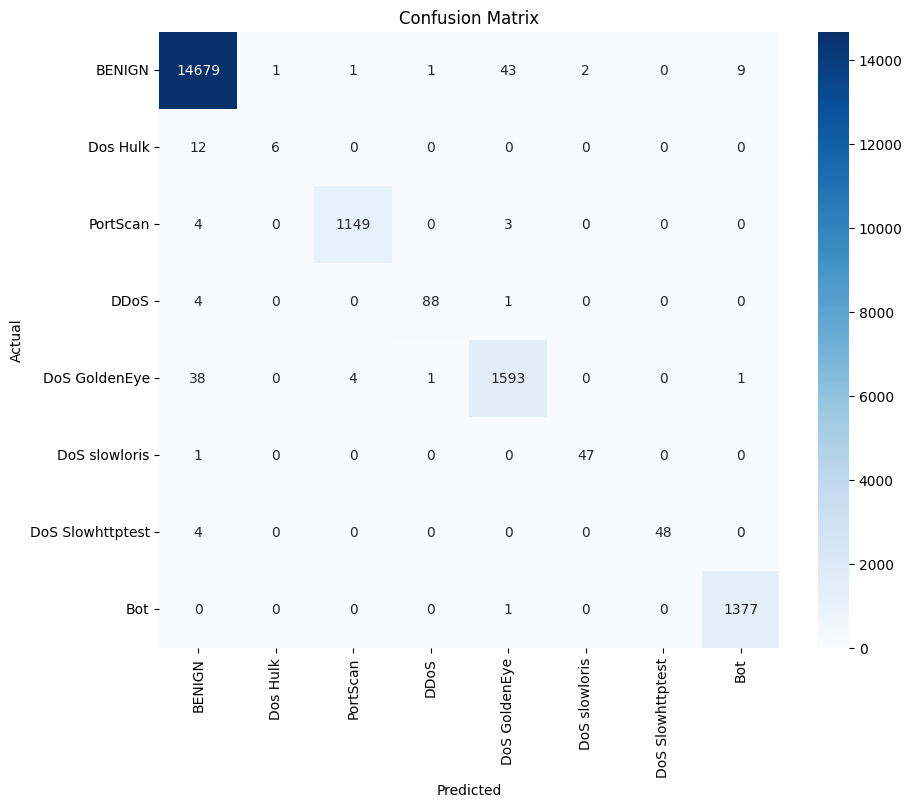

In [73]:
plt.figure(figsize=(10,8))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "Dos Hulk", "PortScan", "DDoS", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest", "Bot"],
    yticklabels=["BENIGN", "Dos Hulk", "PortScan", "DDoS", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest", "Bot"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
# plt.savefig(
#     "../outputs/figures/confusion_matrix.png"
# )
plt.show()


In [77]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
7,Average Packet Size,0.194782
6,Packet Length Std,0.188247
5,Packet Length Mean,0.147269
3,Total Fwd Packets,0.088905
9,Flow IAT Std,0.078782
0,Flow Duration,0.067494
8,Flow IAT Mean,0.058912
4,Total Backward Packets,0.056371
1,Flow Bytes/s,0.049383
2,Flow Packets/s,0.034665
